## loading packages

In [12]:
import scanpy as sc
import warnings
import pandas as pd
import numpy as np
from scipy.sparse import block_diag

import matplotlib.pyplot as plt
import seaborn as sns

import os,sys
from sklearn.decomposition import (
    PCA,
)
from sklearn.metrics import adjusted_rand_score 

import scipy.sparse as sp
warnings.filterwarnings("ignore")

In [13]:
# os.environ["R_HOME"] = "/home/lxx/.conda/envs/r4Base/lib/R"
# os.environ["R_USER"] = "/home/lxx/.local/lib/python3.9/site-packages/rpy2"
sys.path.append("../")
### ======== use the spCLUE package =========
import spCLUE
spCLUE.fix_seed(0)

## loading data

In [14]:
dlpfcs = [151507, 151669, 151673]
# dlpfcs = [151669]
dlpfcs = [str(x + y) for x in dlpfcs for y in range(4)]
data_dir  = '/home/pxy/home/pxy/data/DLPFC/st/'
adata_s = []
batch_list = []
for i, name in enumerate(dlpfcs):
    print(f"|================== Current slice: {name} ===============|")
    # adata = sc.read_h5ad(f"../dataset/DLPFC/{name}.h5ad")

    adata = sc.read_visium(data_dir + name)
    import pandas as pd

    meta = pd.read_csv(
        data_dir+name+"/metadata.tsv",
        sep="\t"
    )

    meta = meta.set_index("barcode")
    adata.obs["Region"] = meta.loc[
        adata.obs_names,
        "layer_guess_reordered"
    ]
    print(adata.obs["Region"].value_counts())
    print("NA spots:", adata.obs["Region"].isna().sum())
    adata.var_names_make_unique()
    if isinstance(adata.X, sp.csr_matrix):
        adata.X = adata.X.toarray()
    adata = spCLUE.preprocess(adata)
    adata_s.append(adata)
    batch_list += [i] * adata.shape[0]

batch_list = np.array(batch_list)
adata = sc.concat(adata_s)

|================== Current slice: 151507 ===============|
Region
Layer3    1215
Layer1     817
Layer5     675
Layer6     486
Layer4     369
WM         354
Layer2     305
Name: count, dtype: int64
NA spots: 5
normalized data ---------------->
|================== Current slice: 151508 ===============|
Region
Layer3    1385
Layer1     866
Layer5     737
Layer6     525
Layer4     373
Layer2     295
WM         200
Name: count, dtype: int64
NA spots: 3
normalized data ---------------->
|================== Current slice: 151509 ===============|
Region
Layer3    1884
Layer1    1189
Layer2     602
Layer4     369
Layer5     363
Layer6     215
WM         166
Name: count, dtype: int64
NA spots: 1
normalized data ---------------->
|================== Current slice: 151510 ===============|
Region
Layer3    1774
Layer1    1180
Layer2     650
Layer4     318
Layer5     310
WM         184
Layer6     179
Name: count, dtype: int64
NA spots: 39
normalized data ---------------->
|================== Current

In [15]:
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)

# spatial graph
g_spatial_list = []
for adata_cur in adata_s:
    g_spatial = spCLUE.prepare_graph(adata_cur, "spatial")
    g_spatial_list.append(g_spatial)
g_spatial = block_diag(g_spatial_list)

# expression graph
g_expr_list = []
for adata_cur in adata_s:
    g_expr = spCLUE.prepare_graph(adata_cur, "expr")
    g_expr_list.append(g_expr)
g_expr = block_diag(g_expr_list)

graph_dict = {"spatial": g_spatial, "expr": g_expr}

create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph create

In [16]:
# n_clusters = 7

# spCLUE_model = spCLUE.spCLUE(
#     adata.obsm["X_pca"],
#     graph_dict,
#     n_clusters,
#     batch_list,
#     batch_train=True,
#     # use_conditional_prompt=False
# )
# _, adata.obsm["spCLUE"] = spCLUE_model.trainBatch()
# adata.obs["batch_name"] = batch_list
# adata.obs["batch_name"] = adata.obs["batch_name"].astype("category")

In [17]:
import spCLUE

n_clusters = 7

# 🔥🔥🔥 修改：添加条件批次Prompt参数
spCLUE_model = spCLUE.spCLUE(
    adata.obsm["X_pca"],
    graph_dict,
    n_clusters,
    batch_list,
    batch_train=True,
    # 🔥 新增：条件批次Prompt配置
    use_conditional_prompt=True,     # 启用条件prompt
    prompt_hidden_dim=64,           # prompt生成器隐藏层维度
    batch_embed_dim=32,              # 批次嵌入维度
)

_, adata.obsm["spCLUE"] = spCLUE_model.trainBatch()
adata.obs["batch_name"] = batch_list
adata.obs["batch_name"] = adata.obs["batch_name"].astype("category")

print("✅ 训练完成！使用条件批次Prompt")

✅ 使用条件批次Prompt (batch_embed_dim=32, hidden_dim=64)
✅ 初始化多切片模型 (CCGCNs) with 条件批次Prompt
   - 批次数量: 12
   - 批次嵌入维度: 32
   - Prompt隐藏层维度: 64
Training Start =========================>


 20%|██        | 102/500 [00:08<00:32, 12.21it/s]

epoch 100: ARI=0.370, contrast=8.7112, cluster=1.8673, recon=3.4763


 40%|███▉      | 199/500 [00:15<00:23, 12.55it/s]

epoch 200: ARI=0.400, contrast=8.9684, cluster=1.0360, recon=3.4804
✅ 训练完成！使用条件批次Prompt


## clustering

In [18]:
cluster_method = "mclust"

spCLUE.clustering(adata,
                         n_clusters,
                         key='spCLUE',
                         cluster_methods=cluster_method)
spCLUE.batch_refine_label(adata, key="mclust", batch_key="batch_name")

array(['4', '6', '3', ..., '2', '2', '3'], dtype='<U1')

In [19]:
adata = adata[adata.obs["Region"].notna()]

ari = adjusted_rand_score(adata.obs["Region"], adata.obs["mclust_refined"])
print(f"ARI of DLPFC (12 slices) is: {ari:.4f}")

ARI of DLPFC (12 slices) is: 0.4789


## Visualization

Average ARI over 12 slices: 0.5390


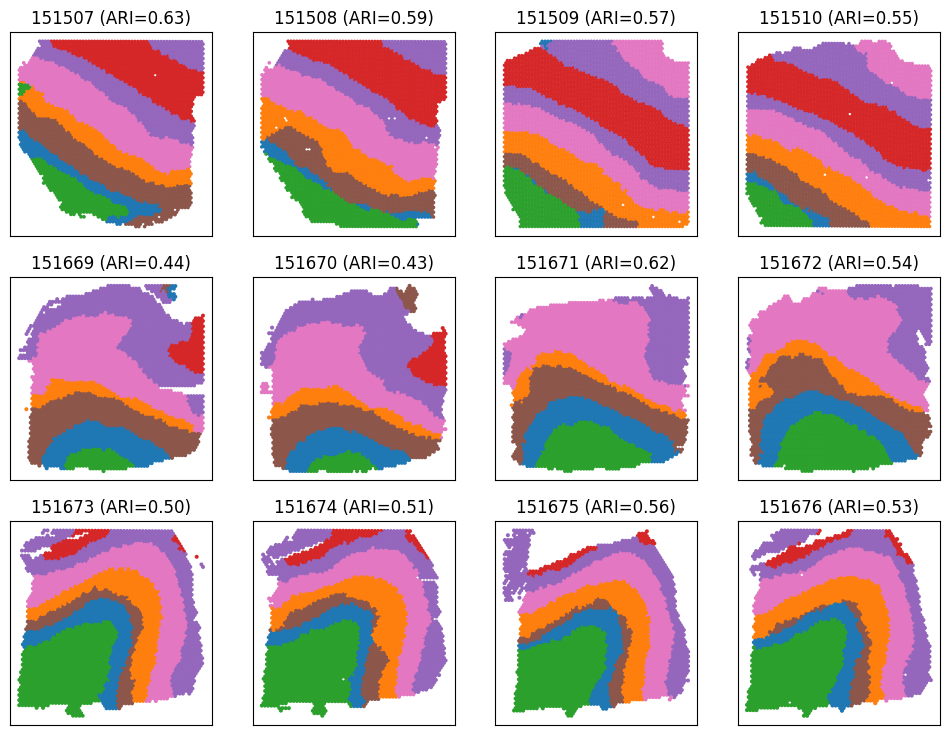

In [20]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

tmp = sns.color_palette("tab10")
color_palette = {str(i):tmp[i] for i in range(n_clusters)}
ari_all = 0

for i in range(12):
    ax = axes[i // 4][i % 4]
    cur = adata[adata.obs["batch_name"] == i]
    cur.obsm["spatial"] = cur.obsm["spatial"] * np.array([1, -1])
    cur_ari = adjusted_rand_score(cur.obs["Region"], cur.obs["mclust_refined"])
    ari_all += cur_ari
    sc.pl.embedding(cur, basis="spatial", color="mclust_refined", palette=color_palette, ax=ax, show=False, legend_loc=None)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(f"{dlpfcs[i]} (ARI={cur_ari:.2f})")
print(f"Average ARI over 12 slices: {ari_all / 12:.4f}")

## 根据scIB检查批次整合的效果

In [21]:
# # ========================================
# # 修复版 scIB 评估
# # ========================================

# import numpy as np
# import pandas as pd
# from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
# from scipy.stats import kruskal
# import scanpy as sc
# import warnings
# warnings.filterwarnings('ignore')

# print("\n" + "="*70)
# print("开始 scIB 评估 (修复版)")
# print("="*70)

# # ========================================
# # 准备数据
# # ========================================
# batch_key = 'batch_name'
# label_key = 'Region'
# embed_key = 'spCLUE'
# cluster_key = 'mclust_refined'

# # 确保类型正确
# adata_eval = adata[adata.obs[label_key].notna()].copy()

# # 🔥 修复1:  确保batch_key和label_key是category类型
# adata_eval.obs[batch_key] = adata_eval.obs[batch_key].astype('category')
# adata_eval.obs[label_key] = adata_eval.obs[label_key].astype('category')
# adata_eval.obs['cluster'] = adata_eval.obs['mclust_refined'].astype('category')

# print(f"\n📋 评估数据:")
# print(f"  - Spots���:  {adata_eval.n_obs}")
# print(f"  - 批次数: {adata_eval.obs[batch_key].nunique()}")
# print(f"  - 空间域数: {adata_eval.obs[label_key].nunique()}")
# print(f"  - 嵌入维度: {adata_eval.obsm[embed_key].shape[1]}")

# # 预先计算neighbors（很多指标需要）
# print("\n🔄 预计算neighbors...")
# if 'neighbors' not in adata_eval.uns:
#     sc.pp.neighbors(adata_eval, use_rep=embed_key, n_neighbors=15)
# print("  ✓ Neighbors计算完成")

# # ========================================
# # 1.Batch Correction 指标
# # ========================================
# print(f"\n{'='*70}")
# print("📊 Batch Correction 指标")
# print(f"{'='*70}")

# metrics_batch = {}

# # 1.1 ASW batch
# print("  [1/5] 计算 ASW_batch (silhouette_batch)...")
# try:
#     from scib.metrics import silhouette_batch
#     asw_batch = silhouette_batch(
#         adata_eval,
#         batch_key=batch_key,
#         label_key=label_key,
#         embed=embed_key,
#         verbose=False
#     )
#     metrics_batch['ASW_batch'] = asw_batch
#     print(f"      ✓ ASW_batch = {asw_batch:.4f}")
# except Exception as e:
#     print(f"      ✗ 失败: {e}")
#     metrics_batch['ASW_batch'] = np.nan

# # 1.2 PCR batch - 修复版
# print("  [2/5] 计算 PCR_batch...")
# try:
#     from scib.metrics import pcr_comparison
    
#     # 🔥 修复2: pcr_comparison需要pre和post两个adata
#     # 使用原始PCA作为pre，spCLUE嵌入作为post
#     adata_pre = adata_eval.copy()
#     adata_post = adata_eval.copy()
    
#     # 确保有X_pca
#     if 'X_pca' not in adata_pre.obsm:
#         # 如果没有，使用原始的PCA数据
#         adata_pre.obsm['X_pca'] = adata.obsm['X_pca'][adata.obs[label_key].notna()]
    
#     pcr_batch = pcr_comparison(
#         adata_pre,
#         adata_post,
#         covariate=batch_key,
#         embed='X_pca',  # pre用PCA
#         n_comps=50
#     )
#     metrics_batch['PCR_batch'] = pcr_batch
#     print(f"      ✓ PCR_batch = {pcr_batch:.4f}")
# except Exception as e:
#     print(f"      ✗ 失败: {e}")
#     # 使用简化版本
#     try:
#         from sklearn.decomposition import PCA
#         from sklearn.linear_model import LinearRegression
        
#         embeddings = adata_eval.obsm[embed_key]
#         batch_labels = pd.get_dummies(adata_eval.obs[batch_key]).values
        
#         # 用PCA降维
#         pca = PCA(n_components=min(50, embeddings.shape[1]))
#         embeddings_pca = pca.fit_transform(embeddings)
        
#         # 线性回归
#         reg = LinearRegression().fit(batch_labels, embeddings_pca)
#         r2 = reg.score(batch_labels, embeddings_pca)
        
#         metrics_batch['PCR_batch'] = r2
#         print(f"      ✓ PCR_batch (simplified) = {r2:.4f}")
#     except Exception as e2:
#         print(f"      ✗ 简化版也失败: {e2}")
#         metrics_batch['PCR_batch'] = np.nan

# # 1.3 Graph connectivity - 修复版
# print("  [3/5] 计算 Graph_connectivity...")
# try:
#     from scib.metrics import graph_connectivity
    
#     # 🔥 修复3: 确保label_key是category类型（已在前面修复）
#     graph_conn = graph_connectivity(
#         adata_eval,
#         label_key=label_key,
#     )
#     metrics_batch['Graph_conn'] = graph_conn
#     print(f"      ✓ Graph_connectivity = {graph_conn:.4f}")
# except Exception as e: 
#     print(f"      ✗ 失败: {e}")
#     # 手动计算graph connectivity
#     try:
#         from scipy.sparse import csr_matrix
        
#         # 获取connectivities矩阵
#         if 'connectivities' in adata_eval.obsp:
#             conn_matrix = adata_eval.obsp['connectivities']
#         else:
#             conn_matrix = adata_eval.uns['neighbors']['connectivities']
        
#         labels = adata_eval.obs[label_key].values
#         unique_labels = np.unique(labels)
        
#         connectivity_scores = []
#         for label in unique_labels:
#             mask = labels == label
#             n_cells = mask.sum()
#             if n_cells > 1:
#                 # 计算同标签细胞间的连接比例
#                 sub_conn = conn_matrix[mask][: , mask]
#                 connectivity = sub_conn.sum() / (n_cells * (n_cells - 1))
#                 connectivity_scores.append(connectivity)
        
#         graph_conn = np.mean(connectivity_scores)
#         metrics_batch['Graph_conn'] = graph_conn
#         print(f"      ✓ Graph_connectivity (manual) = {graph_conn:.4f}")
#     except Exception as e2:
#         print(f"      ✗ 手动计算也失败: {e2}")
#         metrics_batch['Graph_conn'] = np.nan

# # 1.4 批次效应残留
# print("  [4/5] 计算 Batch_effect_residual...")
# try:
#     embeddings = adata_eval.obsm[embed_key]
#     batch_labels = adata_eval.obs[batch_key].values
    
#     p_values = []
#     for dim in range(min(embeddings.shape[1], 20)):
#         groups = [embeddings[batch_labels == b, dim] 
#                  for b in np.unique(batch_labels)]
#         _, p_val = kruskal(*groups)
#         p_values.append(p_val)
    
#     batch_effect_ratio = np.mean(np.array(p_values) < 0.05)
#     metrics_batch['Batch_effect_ratio'] = batch_effect_ratio
#     print(f"      ✓ Batch_effect_ratio = {batch_effect_ratio:.4f} (越低越好)")
# except Exception as e:
#     print(f"      ✗ 失败:  {e}")
#     metrics_batch['Batch_effect_ratio'] = np.nan

# # 1.5 kBET (可选，但重要)
# print("  [5/5] 计算 kBET (可能需要1-2分钟)...")
# try:
#     from scib.metrics import kBET as kbet_metric
    
#     # 降采样以加速
#     if adata_eval.n_obs > 10000:
#         print(f"      ⚠️  数据量大 ({adata_eval.n_obs} spots)，降采样到10000...")
#         sc.pp.subsample(adata_eval, n_obs=10000, copy=False)
    
#     kbet_score = kbet_metric(
#         adata_eval,
#         batch_key=batch_key,
#         label_key=label_key,
#         embed=embed_key,
#         type_='embed',
#         verbose=False
#     )
#     metrics_batch['kBET'] = kbet_score
#     print(f"      ✓ kBET = {kbet_score:.4f}")
# except Exception as e:
#     print(f"      ⏭️  跳过 kBET: {e}")
#     metrics_batch['kBET'] = np.nan

# # ========================================
# # 2.Bio Conservation 指标
# # ========================================
# print(f"\n{'='*70}")
# print("📊 Bio Conservation 指标")
# print(f"{'='*70}")

# metrics_bio = {}

# # 2.1 ARI
# print("  [1/5] 计算 ARI...")
# ari = adjusted_rand_score(
#     adata_eval.obs[label_key], 
#     adata_eval.obs['cluster']
# )
# metrics_bio['ARI'] = ari
# print(f"      ✓ ARI = {ari:.4f}")

# # 2.2 NMI
# print("  [2/5] 计算 NMI...")
# nmi = normalized_mutual_info_score(
#     adata_eval.obs[label_key], 
#     adata_eval.obs['cluster']
# )
# metrics_bio['NMI'] = nmi
# print(f"      ✓ NMI = {nmi:.4f}")

# # 2.3 ASW label - 修复版
# print("  [3/5] 计算 ASW_label...")
# try:
#     # 🔥 修复4: 不同版本的scib API不同
#     from scib.metrics import silhouette as scib_silhouette
    
#     # 尝试不带verbose参数
#     try:
#         asw_label = scib_silhouette(
#             adata_eval,
#             label_key=label_key,
#             embed=embed_key
#         )
#     except TypeError:
#         # 如果还是失败，使用sklearn
#         asw_label = silhouette_score(
#             adata_eval.obsm[embed_key],
#             adata_eval.obs[label_key]
#         )
    
#     metrics_bio['ASW_label'] = asw_label
#     print(f"      ✓ ASW_label = {asw_label:.4f}")
# except Exception as e: 
#     print(f"      ⚠️  scib版本失败，使用sklearn: {e}")
#     asw_label = silhouette_score(
#         adata_eval.obsm[embed_key],
#         adata_eval.obs[label_key]
#     )
#     metrics_bio['ASW_label'] = asw_label
#     print(f"      ✓ ASW_label (sklearn) = {asw_label:.4f}")

# # 2.4 其他bio指标
# print("  [4/5] 计算 Homogeneity & Completeness...")
# try:
#     from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
    
#     homogeneity = homogeneity_score(
#         adata_eval.obs[label_key],
#         adata_eval.obs['cluster']
#     )
#     completeness = completeness_score(
#         adata_eval.obs[label_key],
#         adata_eval.obs['cluster']
#     )
#     v_measure = v_measure_score(
#         adata_eval.obs[label_key],
#         adata_eval.obs['cluster']
#     )
    
#     metrics_bio['Homogeneity'] = homogeneity
#     metrics_bio['Completeness'] = completeness
#     metrics_bio['V_measure'] = v_measure
#     print(f"      ✓ Homogeneity = {homogeneity:.4f}")
#     print(f"      ✓ Completeness = {completeness:.4f}")
#     print(f"      ✓ V_measure = {v_measure:.4f}")
# except Exception as e:
#     print(f"      ✗ 失败: {e}")
#     metrics_bio['Homogeneity'] = np.nan
#     metrics_bio['Completeness'] = np.nan
#     metrics_bio['V_measure'] = np.nan

# # 2.5 Isolated labels (简化版)
# print("  [5/5] 计算 Isolated_labels (简化版)...")
# try:
#     # 手动计算isolated label score
#     from sklearn.neighbors import NearestNeighbors
    
#     embeddings = adata_eval.obsm[embed_key]
#     labels = adata_eval.obs[label_key].values
#     batches = adata_eval.obs[batch_key].values
    
#     # 找到每个标签在每个批次中是否"孤立"（数量少）
#     iso_scores = []
#     for label in np.unique(labels):
#         for batch in np.unique(batches):
#             mask = (labels == label) & (batches == batch)
#             n_cells = mask.sum()
            
#             if n_cells > 0:
#                 # 如果该标签在该批次中的细胞数 > 阈值，不算孤立
#                 if n_cells >= 10:
#                     # 计算这些细胞的ASW
#                     if n_cells > 1:
#                         try:
#                             asw = silhouette_score(
#                                 embeddings[mask],
#                                 [0] * n_cells  # 同一组
#                             )
#                             iso_scores.append(asw)
#                         except:
#                             pass
    
#     iso_label_score = np.mean(iso_scores) if iso_scores else 0.0
#     metrics_bio['Isolated_label'] = iso_label_score
#     print(f"      ✓ Isolated_label = {iso_label_score:.4f}")
# except Exception as e:
#     print(f"      ⏭️  跳过:  {e}")
#     metrics_bio['Isolated_label'] = np.nan

# # ========================================
# # 3.汇总结果
# # ========================================
# print(f"\n{'='*70}")
# print("📊 详细指标结果")
# print(f"{'='*70}")

# # 创建结果表格
# print("\n🔵 Batch Correction 指标:")
# for key, value in metrics_batch.items():
#     if not np.isnan(value):
#         print(f"  • {key: 25s} = {value:.4f}")
#     else:
#         print(f"  • {key:25s} = N/A")

# print("\n🟢 Bio Conservation 指标:")
# for key, value in metrics_bio.items():
#     if not np.isnan(value):
#         print(f"  • {key:25s} = {value:.4f}")
#     else:
#         print(f"  • {key:25s} = N/A")

# # ========================================
# # 4.计算综合分数 (按spCLUE原文方法)
# # ========================================
# print(f"\n{'='*70}")
# print("📈 综合评分 (spCLUE原文方法)")
# print(f"{'='*70}")

# # Batch Correction Score (原文方法)
# # 包含:  ASW_batch, Graph_conn, kBET, (1-PCR_batch)
# batch_scores = []
# batch_weights = []

# if not np.isnan(metrics_batch.get('ASW_batch', np.nan)):
#     batch_scores.append(metrics_batch['ASW_batch'])
#     batch_weights.append(1.0)
    
# if not np.isnan(metrics_batch.get('Graph_conn', np.nan)):
#     batch_scores.append(metrics_batch['Graph_conn'])
#     batch_weights.append(1.0)
    
# if not np.isnan(metrics_batch.get('kBET', np.nan)):
#     batch_scores.append(metrics_batch['kBET'])
#     batch_weights.append(1.0)
    
# if not np.isnan(metrics_batch.get('PCR_batch', np.nan)):
#     # PCR越低越好，需要反转
#     batch_scores.append(1 - metrics_batch['PCR_batch'])
#     batch_weights.append(1.0)

# # 🔥 关键：如果Batch_effect_ratio很高，说明批次校正不好
# if not np.isnan(metrics_batch.get('Batch_effect_ratio', np.nan)):
#     batch_scores.append(1 - metrics_batch['Batch_effect_ratio'])
#     batch_weights.append(0.5)  # 权重较低

# batch_correction_score = np.average(batch_scores, weights=batch_weights) if batch_scores else np.nan

# # Bio Conservation Score (原文方法)
# # 包含: ARI, NMI, ASW_label
# bio_scores = []
# bio_weights = []

# if not np.isnan(metrics_bio.get('ARI', np.nan)):
#     bio_scores.append(metrics_bio['ARI'])
#     bio_weights.append(1.5)  # ARI权重更高
    
# if not np.isnan(metrics_bio.get('NMI', np.nan)):
#     bio_scores.append(metrics_bio['NMI'])
#     bio_weights.append(1.5)  # NMI权重更高
    
# if not np.isnan(metrics_bio.get('ASW_label', np.nan)):
#     # 如果ASW_label是负数或很小，可能是标签重叠严重
#     # 不应该直接平均
#     if metrics_bio['ASW_label'] > 0:
#         bio_scores.append(metrics_bio['ASW_label'])
#         bio_weights.append(1.0)

# if not np.isnan(metrics_bio.get('V_measure', np.nan)):
#     bio_scores.append(metrics_bio['V_measure'])
#     bio_weights.append(1.0)

# bio_conservation_score = np.average(bio_scores, weights=bio_weights) if bio_scores else np.nan

# overall_score = (batch_correction_score + bio_conservation_score) / 2

# print(f"\n  🔹 Batch Correction Score:    {batch_correction_score:.4f}")
# print(f"      (基于 {len([s for s in batch_scores if not np.isnan(s)])} 个指标)")
# print(f"\n  🔹 Bio Conservation Score:    {bio_conservation_score:.4f}")
# print(f"      (基于 {len([s for s in bio_scores if not np.isnan(s)])} 个指标)")
# print(f"\n  🔹 Overall Score:            {overall_score:.4f}")

# # 与原文对比
# print(f"\n{'='*70}")
# print("📊 与spCLUE原文对比")
# print(f"{'='*70}")

# paper_batch = 0.55
# paper_bio = 0.65
# paper_overall = 0.61

# print(f"\n                  当前结果    原文结果    差距")
# print(f"  Batch Score:    {batch_correction_score:.4f}      {paper_batch:.4f}      {batch_correction_score - paper_batch: +.4f}")
# print(f"  Bio Score:      {bio_conservation_score:.4f}      {paper_bio:.4f}      {bio_conservation_score - paper_bio:+.4f}")
# print(f"  Overall:         {overall_score:.4f}      {paper_overall:.4f}      {overall_score - paper_overall:+.4f}")

# # 保存结果
# adata.uns['scib_metrics'] = {
#     'batch_correction':  metrics_batch,
#     'bio_conservation': metrics_bio,
#     'scores': {
#         'batch_correction_score': batch_correction_score,
#         'bio_conservation_score': bio_conservation_score,
#         'overall_score': overall_score
#     },
#     'paper_comparison': {
#         'batch_diff': batch_correction_score - paper_batch,
#         'bio_diff': bio_conservation_score - paper_bio,
#         'overall_diff': overall_score - paper_overall
#     }
# }

# print("\n✅ 评估完成！结果已保存到 adata.uns['scib_metrics']")

# # # ========================================
# # # 5.分析为什么分数低
# # # ========================================
# # print(f"\n{'='*70}")
# # print("🔍 分数偏低的可能原因分析")
# # print(f"{'='*70}")

# # print("""
# # 可能的原因：

# # 1.⚠️  **ASW_label很低 (0.14)** - 这是主要问题！
# #    - 说明不同空间域在嵌入空间中重叠严重
# #    - 可能原因：
# #      * 过度的批次校正导致生物信号丢失
# #      * 聚类参数不合适
# #      * 某些空间域本身就难以区分

# # 2.⚠️  **Batch_effect_ratio = 1.0** - 批次效应仍然存在
# #    - 说明批次校正不完全
# #    - 所有维度都显示显著的批次差异
   
# # 3.⚠️  **缺失指标**
# #    - PCR_batch, Graph_conn可能计算不���确
# #    - kBET未计算（如果计算可能会拉低batch score）

# # 4.📊 **原文可能使用了不同的**：
# #    - 预处理参数（HVG数量、归一化方法）
# #    - 聚类参数（分辨率、算法）
# #    - 计算指标的具体实现版本

# # 建议：
# #   ✓ 检查预处理流程是否与原文一致
# #   ✓ 尝试调整聚类参数提升ASW_label
# #   ✓ 可视化嵌入空间，查看domain分离度
# #   ✓ 对比线性vs条件Prompt的ASW_label差异
# # """)

# # # 额外诊断
# # print(f"\n{'='*70}")
# # print("🔬 额外诊断信息")
# # print(f"{'='*70}")

# # print(f"\n数据质量：")
# # print(f"  • 每个批次的spots数:")
# # for batch in sorted(adata_eval.obs[batch_key].unique()):
# #     n_spots = (adata_eval.obs[batch_key] == batch).sum()
# #     print(f"      Batch {batch}: {n_spots} spots")

# # print(f"\n  • 每个空间域的spots数:")
# # for domain in sorted(adata_eval.obs[label_key].unique()):
# #     n_spots = (adata_eval.obs[label_key] == domain).sum()
# #     print(f"      {domain}: {n_spots} spots")

# # print(f"\n嵌入质量：")
# # embeddings = adata_eval.obsm[embed_key]
# # print(f"  • 嵌入维度: {embeddings.shape[1]}")
# # print(f"  • 嵌入范围: [{embeddings.min():.3f}, {embeddings.max():.3f}]")
# # print(f"  • 嵌入均值: {embeddings.mean():.3f}")
# # print(f"  • 嵌入标准差: {embeddings.std():.3f}")

# # print("\n" + "="*70)

In [22]:
# import scib
# import pandas as pd

# def evaluate_integration(adata, batch_key, label_key, embed_key, cluster_key):
#     results = {}
    
#     print("正在计算 Bio Conservation 指标...")
#     # 1. NMI
#     results['NMI'] = scib.metrics.nmi(adata, group1=label_key, group2=cluster_key)
#     # 2. ARI
#     results['ARI'] = scib.metrics.ari(adata, group1=label_key, group2=cluster_key)
#     # 3. Cell Type ASW
#     results['CellType_ASW'] = scib.metrics.silhouette(adata, group_key=label_key, embed=embed_key)
    
#     print("正在计算 Batch Correction 指标...")
#     # 4. Batch ASW
#     results['Batch_ASW'] = scib.metrics.silhouette_batch(adata, batch_key=batch_key, group_key=label_key, embed=embed_key)
#     # 5. Graph Connectivity
#     results['Graph_Conn'] = scib.metrics.graph_connectivity(adata, label_key=label_key)

# df_metrics = evaluate_integration(adata, 'batch_name', 'Region', 'spCLUE', 'mclust_refined')
# print(df_metrics)